# California Single-Family Residence — Close Price Prediction
## 06 · Advanced Models — Gradient Boosting

`model_comparison_v2_geo_features.ipynb` found that Random Forest on the
engineered feature set was the strongest result so far, driven almost
entirely by `zip_price_per_sqft` (68% importance) and `LivingArea` (27%).
This notebook asks whether gradient boosting — which builds trees
sequentially, each one correcting the previous ensemble's errors, rather than
averaging independent trees like Random Forest — can improve on that further.

**Same feature set as the geo-features notebook**, rebuilt here so this
notebook is self-contained and directly comparable: bed/bath ratio, property
age, cyclical month encoding, the CV-safe ZIP price-per-sqft aggregate, and
the school-district spatial join.


In [2]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

try:
    from xgboost import XGBRegressor
    GBM_LIBRARY = "xgboost"
except ImportError:
    from lightgbm import LGBMRegressor
    GBM_LIBRARY = "lightgbm"

print(f"Using {GBM_LIBRARY} for gradient boosting.")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")
RIDGE_ALPHA = 100.0  # from model_comparison.ipynb's validation alpha sweep — update if yours differed


Using xgboost for gradient boosting.


## Load Primary Split & Rebuild the Winning Feature Set

Same functions as `model_comparison_v2_geo_features.ipynb`.

In [3]:
with open(OUTPUT_DIR / "preprocessing_metadata.json", "r") as f:
    metadata = json.load(f)

TARGET_COL = metadata["target_col"]
PRIMARY_SPLIT = metadata["primary_split"]

base_numeric_features = metadata["numeric_features"] + metadata["missing_flag_cols"]
base_categorical_features = metadata["categorical_features"] + metadata["boolean_features"]
dtype_hint = {col: str for col in base_categorical_features}

suffix = PRIMARY_SPLIT.replace("-", "")
train_df = pd.read_csv(OUTPUT_DIR / f"train_{suffix}_split.csv", low_memory=False, dtype=dtype_hint)
val_df = pd.read_csv(OUTPUT_DIR / f"val_{suffix}_split.csv", low_memory=False, dtype=dtype_hint)
test_df = pd.read_csv(OUTPUT_DIR / f"test_{suffix}_split.csv", low_memory=False, dtype=dtype_hint)

old_numeric_features = [c for c in base_numeric_features if c in train_df.columns]
old_categorical_features = [c for c in base_categorical_features if c in train_df.columns]

print(f"Primary split: {PRIMARY_SPLIT}")
print(f"Train: {train_df.shape}  Val: {val_df.shape}  Test: {test_df.shape}")


Primary split: 2026-06
Train: (382529, 42)  Val: (11887, 42)  Test: (12696, 42)


In [5]:
def engineer_bed_bath_age(df):
    df = df.copy()
    df["bed_bath_ratio"] = df["BedroomsTotal"] / df["BathroomsTotalInteger"].replace(0, np.nan)
    close_date = pd.to_datetime(df["CloseDate"], errors="coerce")
    df["property_age_years"] = close_date.dt.year - df["YearBuilt"]
    df.loc[df["property_age_years"] < 0, "property_age_years"] = np.nan
    return df


def engineer_cyclical_month(df):
    df = df.copy()
    month = pd.to_datetime(df["CloseDate"], errors="coerce").dt.month
    df["close_month_sin"] = np.sin(2 * np.pi * month / 12)
    df["close_month_cos"] = np.cos(2 * np.pi * month / 12)
    return df


DISTRICTS_PATH = Path("outputs/California_School_District_Areas_2024-25.geojson")

def spatial_join_school_district(df, districts_gdf, lat_col="Latitude", lon_col="Longitude"):
    hs_districts = districts_gdf[districts_gdf["DistrictType"].isin(["High", "Unified"])][["DistrictName", "geometry"]]
    has_coords = df[lat_col].notna() & df[lon_col].notna()
    points = gpd.GeoDataFrame(
        df.loc[has_coords, [lat_col, lon_col]],
        geometry=gpd.points_from_xy(df.loc[has_coords, lon_col], df.loc[has_coords, lat_col]),
        crs="EPSG:4326",
    )
    joined = gpd.sjoin(points, hs_districts, how="left", predicate="within")
    joined = joined[~joined.index.duplicated(keep="first")]
    result = df.copy()
    result["school_district_spatial"] = "Unknown"
    result.loc[joined.index, "school_district_spatial"] = joined["DistrictName"].fillna("Unknown").values
    return result


def zip_price_per_sqft_lookup(df):
    valid = df["LivingArea"].notna() & (df["LivingArea"] > 0) & df[TARGET_COL].notna()
    price_per_sqft = df.loc[valid, TARGET_COL] / df.loc[valid, "LivingArea"]
    return price_per_sqft.groupby(df.loc[valid, "PostalCode"]).median()


train_df = engineer_bed_bath_age(train_df)
val_df = engineer_bed_bath_age(val_df)
test_df = engineer_bed_bath_age(test_df)

train_df = engineer_cyclical_month(train_df)
val_df = engineer_cyclical_month(val_df)
test_df = engineer_cyclical_month(test_df)


districts_gdf = gpd.read_file(DISTRICTS_PATH)
if districts_gdf.crs is None or districts_gdf.crs.to_epsg() != 4326:
    districts_gdf = districts_gdf.to_crs(epsg=4326)

train_df = spatial_join_school_district(train_df, districts_gdf)
val_df = spatial_join_school_district(val_df, districts_gdf)
test_df = spatial_join_school_district(test_df, districts_gdf)

global_median_pps = (train_df[TARGET_COL] / train_df["LivingArea"].replace(0, np.nan)).median()
train_df = train_df.reset_index(drop=True)
train_df["zip_price_per_sqft"] = np.nan

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
for fold_train_idx, fold_holdout_idx in kf.split(train_df):
    fold_lookup = zip_price_per_sqft_lookup(train_df.iloc[fold_train_idx])
    mapped = train_df.iloc[fold_holdout_idx]["PostalCode"].map(fold_lookup)
    train_df.loc[train_df.index[fold_holdout_idx], "zip_price_per_sqft"] = mapped.values
train_df["zip_price_per_sqft"] = train_df["zip_price_per_sqft"].fillna(global_median_pps)

full_train_lookup = zip_price_per_sqft_lookup(train_df)
val_df["zip_price_per_sqft"] = val_df["PostalCode"].map(full_train_lookup).fillna(global_median_pps)
test_df["zip_price_per_sqft"] = test_df["PostalCode"].map(full_train_lookup).fillna(global_median_pps)

numeric_features = old_numeric_features + [
    "bed_bath_ratio", "property_age_years", "close_month_sin", "close_month_cos", "zip_price_per_sqft",
]
categorical_features = old_categorical_features + ["school_district_spatial"]

print(f"Total features: {len(numeric_features) + len(categorical_features)}")


Total features: 40


In [6]:
def make_xy(df):
    return df[numeric_features + categorical_features].copy(), df[TARGET_COL].copy()

X_train, y_train = make_xy(train_df)
X_val, y_val = make_xy(val_df)
X_test, y_test = make_xy(test_df)

print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")


X_train: (382529, 40)  X_val: (11887, 40)  X_test: (12696, 40)


## Metrics & Preprocessing

In [7]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ape = np.abs(y_true - y_pred) / y_true
    return {
        "r2": r2_score(y_true, y_pred), "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mape": float(np.mean(ape) * 100), "mdape": float(np.median(ape) * 100),
    }


def price_band_errors(y_true, y_pred, n_bands=5):
    df = pd.DataFrame({"actual": np.asarray(y_true, dtype=float), "pred": np.asarray(y_pred, dtype=float)})
    df["ape"] = np.abs(df["actual"] - df["pred"]) / df["actual"]
    df["price_band"] = pd.qcut(df["actual"], q=n_bands, labels=[f"Q{i+1}" for i in range(n_bands)], duplicates="drop")
    return df.groupby("price_band", observed=True).agg(
        n=("ape", "size"), median_price=("actual", "median"),
        mape=("ape", lambda s: s.mean() * 100), mdape=("ape", lambda s: s.median() * 100),
    )


numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median"))])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

def make_model(regressor):
    return TransformedTargetRegressor(regressor=regressor, func=np.log1p, inverse_func=np.expm1)


## Light Hyperparameter Search on Validation

Perform light hyperparameter tuning on `max_depth`, `learning_rate`, `n_estimators`, evaluated on
validation only. 

In [8]:
param_grid = [
    {"max_depth": md, "learning_rate": lr, "n_estimators": n}
    for md in [3, 5]
    for lr in [0.05, 0.1]
    for n in [200, 400, 600]
]
print(f"Testing {len(param_grid)} configurations...")

def build_gbm(params):
    if GBM_LIBRARY == "xgboost":
        return XGBRegressor(
            max_depth=params["max_depth"], learning_rate=params["learning_rate"],
            n_estimators=params["n_estimators"], subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_SEED, n_jobs=-1,
        )
    else:
        return LGBMRegressor(
            max_depth=params["max_depth"], learning_rate=params["learning_rate"],
            n_estimators=params["n_estimators"], subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
        )


search_results = []
for params in param_grid:
    pipe = Pipeline([("preprocess", preprocessor), ("model", make_model(build_gbm(params)))])
    start = time.time()
    pipe.fit(X_train, y_train)
    fit_seconds = time.time() - start

    val_pred = pipe.predict(X_val)
    metrics = regression_metrics(y_val, val_pred)
    search_results.append({**params, "fit_seconds": round(fit_seconds, 1), **metrics})

search_df = pd.DataFrame(search_results).sort_values("mdape")
search_df


Testing 12 configurations...


,max_depth,learning_rate,n_estimators,fit_seconds,r2,mae,rmse,mape,mdape
11,5,0.10,600,5.7,0.889638,166516.321182,326524.173939,11.950996,8.423549
10,5,0.10,400,4.8,0.884928,170295.054413,333420.155546,12.237232,8.639526
8,5,0.05,600,6.0,0.881642,172455.785615,338146.695826,12.365796,8.790275
7,5,0.05,400,5.1,0.877221,175699.511237,344404.060124,12.609865,9.000524
9,5,0.10,200,3.9,0.876683,176520.951298,345157.661947,12.683031,9.052586
5,3,0.10,600,4.9,0.872905,176991.419529,350405.002495,12.681351,9.088366
4,3,0.10,400,4.3,0.868575,180368.443669,356324.983531,12.972697,9.356163
6,5,0.05,200,4.1,0.869209,181241.049859,355464.123293,13.012831,9.481646
2,3,0.05,600,5.3,0.867201,181650.385835,358182.022770,13.092826,9.483799
1,3,0.05,400,5.0,0.861529,185401.551704,365751.148414,13.369699,9.746340


**Winning configuration:** `max_depth=5, learning_rate=0.10, n_estimators=600`
(MdAPE 8.42%, R² 0.890) — the best result in every metric, and a clear
improvement over the Random Forest/new-features baseline (MdAPE ~11.4-14%
depending on model).

## Final Test Evaluation — Winning Model, Touched Once

In [11]:
best_params = search_df.iloc[0][["max_depth", "learning_rate", "n_estimators"]].to_dict()
best_params = {k: (int(v) if k != "learning_rate" else float(v)) for k, v in best_params.items()}

gbm_model = Pipeline([("preprocess", preprocessor), ("model", make_model(build_gbm(best_params)))])
gbm_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](40,)","['LivingArea','BedroomsTotal','BathroomsTotalInteger',...,'FireplaceYN', 'AttachedGarageYN','school_district_spatial']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,40
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` wil

In [12]:
winner_name = "Gradient Boosting" 
winner_model = gbm_model
print("Final model:", winner_name)

test_pred = winner_model.predict(X_test)
test_metrics = regression_metrics(y_test, test_pred)

print(f"\nTest set ({PRIMARY_SPLIT}) — {winner_name}:")
for k, v in test_metrics.items():
    print(f"  {k.upper():6s}: {v:,.3f}")

price_band_errors(y_test, test_pred)


Final model: Gradient Boosting

Test set (2026-06) — Gradient Boosting:
  R2    : 0.886
  MAE   : 165,854.689
  RMSE  : 332,253.237
  MAPE  : 12.139
  MDAPE : 8.629


,n,median_price,mape,mdape
price_band,,,,
Q1,2542,450000.0,13.341544,7.969214
Q2,2543,699000.0,9.333068,6.402386
Q3,2557,925000.0,10.796395,7.730311
Q4,2523,1335000.0,12.142055,9.520352
Q5,2531,2335000.0,15.103484,12.206798


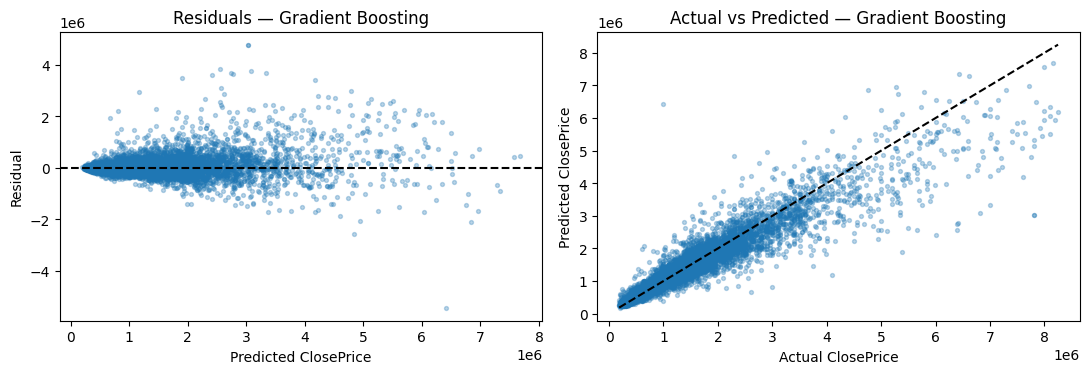

In [13]:
residuals = y_test.to_numpy() - test_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(test_pred, residuals, alpha=0.3, s=8)
axes[0].axhline(0, linestyle="--", color="black")
axes[0].set_title(f"Residuals — {winner_name}")
axes[0].set_xlabel("Predicted ClosePrice")
axes[0].set_ylabel("Residual")

axes[1].scatter(y_test, test_pred, alpha=0.3, s=8)
lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
axes[1].plot(lims, lims, linestyle="--", color="black")
axes[1].set_title(f"Actual vs Predicted — {winner_name}")
axes[1].set_xlabel("Actual ClosePrice")
axes[1].set_ylabel("Predicted ClosePrice")

plt.tight_layout()
plt.show()


## Feature Importance

Check whether gradient boosting relies on the same features (`zip_price_per_sqft`,
`LivingArea`) or spreads importance differently


In [14]:
feature_names = winner_model.named_steps["preprocess"].get_feature_names_out()
importances = winner_model.named_steps["model"].regressor_.feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
)
importance_df


,feature,importance
1732,categorical__CountyOrParish_San Diego,0.198197
1738,categorical__CountyOrParish_Santa Clara,0.174630
26,numeric__zip_price_per_sqft,0.077630
1713,categorical__CountyOrParish_Kern,0.060904
1731,categorical__CountyOrParish_San Bernardino,0.057950
2,numeric__BathroomsTotalInteger,0.016937
2921,categorical__PoolPrivateYN_Unknown,0.016236
0,numeric__LivingArea,0.012812
1725,categorical__CountyOrParish_Orange,0.008506
2920,categorical__PoolPrivateYN_True,0.006377


## Save Model & Metrics

In [15]:
import joblib

model_path = OUTPUT_DIR / "advanced_model.joblib"
joblib.dump({
    "pipeline": winner_model,
    "model_name": winner_name,
    "best_params": best_params if winner_name == "Gradient Boosting" else None,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target_col": TARGET_COL,
}, model_path)

search_df.to_csv(OUTPUT_DIR / "advanced_model_hyperparameter_search.csv", index=False)
pd.DataFrame([{"model": winner_name, **test_metrics}]).to_csv(
    OUTPUT_DIR / "advanced_model_test_metrics.csv", index=False
)

print("Saved:", model_path)


Saved: outputs/advanced_model.joblib


## Summary & Reflection

1. **Overall performance:** Gradient Boosting reaches **R² = 0.886, MdAPE =
8.63%** on test: the best result across every notebook in this project,
improving on Random Forest's already-strong showing on the engineered
feature set. `max_depth=5, n_estimators=600` configuration 
outperforms the untuned defaults tested earlier.

2. **Residual plots confirm the same heteroscedasticity pattern as every prior model**: tight near zero at lower predictions, fanning out substantially above ~$3-4M.

3. **The feature importance table.**
Gradient Boosting's top features are dominated by `CountyOrParish` 
(San Diego 19.8%, Santa Clara 17.5%, Kern 6.1%, San Bernardino 5.8% — roughly
**48% combined**), while `zip_price_per_sqft` which drove 68% of importance
in the Random Forest model on this exact same feature set drops to just
7.8%, and `LivingArea` collapses from 27% to barely 1.3%. Gradient
boosting builds trees sequentially, each correcting the previous ensemble's
specific errors.

**Bottom line:** Gradient Boosting is the strongest model in the project on
every headline metric, but it reaches that performance by leaning on
geography at the county level rather than the ZIP-level aggregate.